<a href="https://colab.research.google.com/github/ag-coder05/Data_Science_Intership_Assignments/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

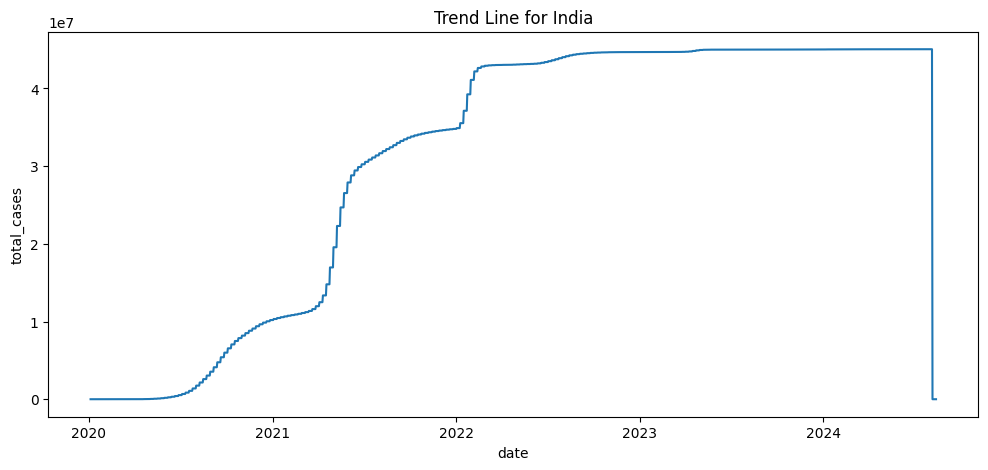

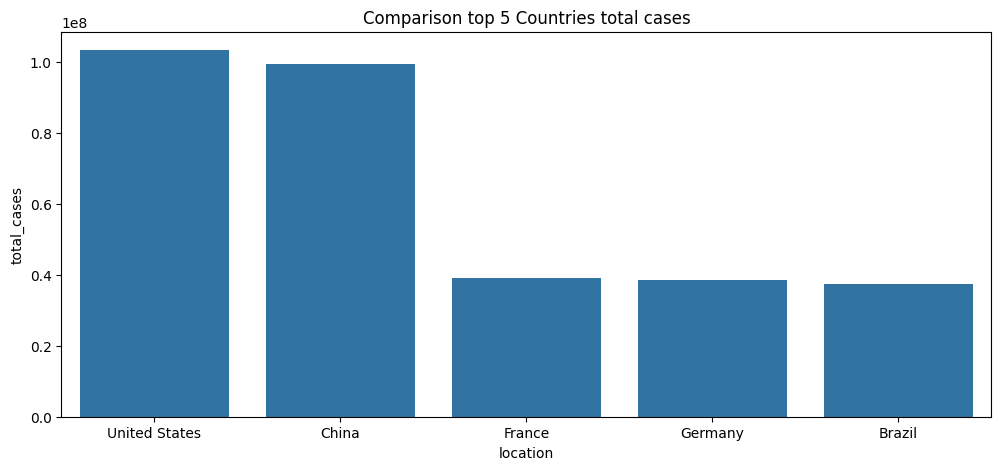

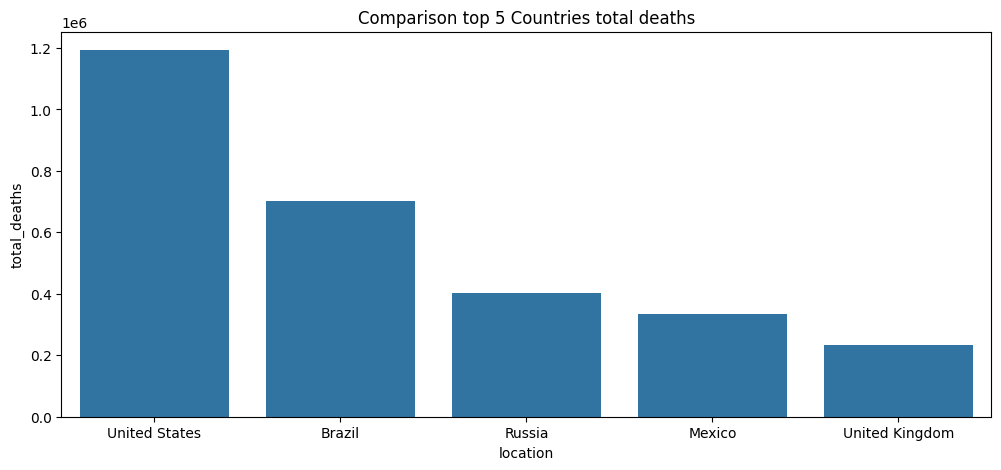

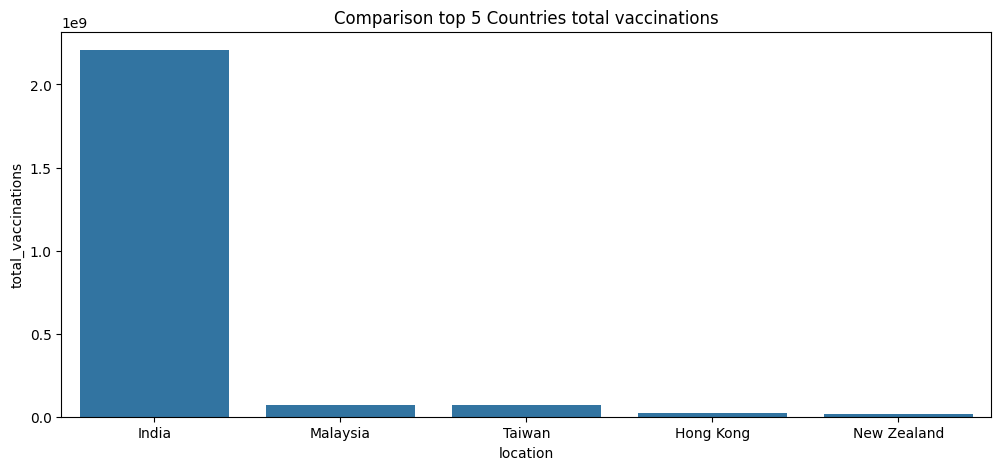

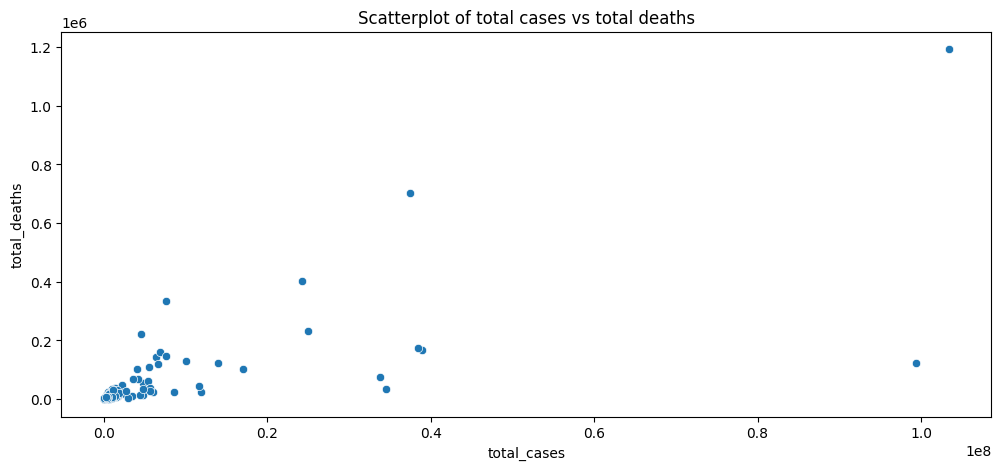

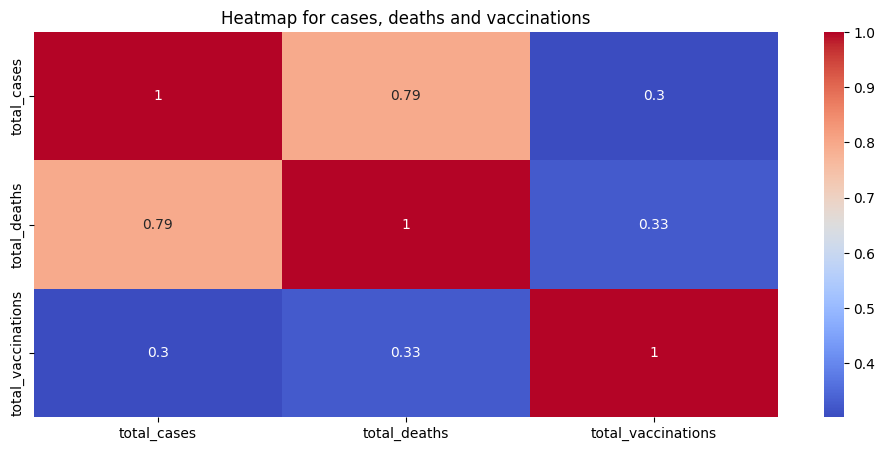

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url='https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'
df=pd.read_csv(url)
df.head()
#data cleaning
#date conversion
df['date']=pd.to_datetime(df['date'])
#remove rows whose location is not valid country
df = df[~df['iso_code'].str.startswith('OWID', na=False)]
#fill missing data of required columns
df[['total_cases', 'total_deaths', 'total_vaccinations']]=df[['total_cases', 'total_deaths', 'total_vaccinations']].fillna(0)

#Task1: plot trend line(example India)
plt.figure(figsize=(12,5))
sns.lineplot(data=df[df['location']=='India'], x='date', y='total_cases')
plt.title('Trend Line for India')
plt.show()

#Task2 : Compare top 5 countries total cases, total deaths, total vaccinations
grp= df.groupby('location').last().nlargest(5, 'total_cases')
plt.figure(figsize=(12,5))
sns.barplot(data=grp, x='location', y='total_cases')
plt.title('Comparison top 5 Countries total cases')
plt.show()

grp= df.groupby('location').last().nlargest(5, 'total_deaths')
plt.figure(figsize=(12,5))
sns.barplot(data=grp, x='location', y='total_deaths')
plt.title('Comparison top 5 Countries total deaths')
plt.show()

grp= df.groupby('location').last().nlargest(5, 'total_vaccinations')
plt.figure(figsize=(12,5))
sns.barplot(data=grp, x='location', y='total_vaccinations')
plt.title('Comparison top 5 Countries total vaccinations')
plt.show()


#Task3: Scatterplot of cases vs deaths
grpp= df.groupby('location').last()
plt.figure(figsize=(12,5))
sns.scatterplot(data=grpp, x='total_cases', y='total_deaths')
plt.title('Scatterplot of total cases vs total deaths')
plt.show()

#Task4: Heatmap
plt.figure(figsize=(12,5))
num = df[['total_cases', 'total_deaths', 'total_vaccinations']]
sns.heatmap(data=num.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap for cases, deaths and vaccinations')
plt.show()


